## Importando configurações e bibliotecas necessárias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Evitar erros quando criar o modelo KNN.
import os

os.environ['OMP_NUM_THREADS'] = '1'

## Importação e compreensão de dados



In [3]:
baseData= pd.read_csv('train.csv')

In [4]:
baseData.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Analisando colunas com valores nulos.
baseData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
# Analisando possível duplicidade nos dados.
baseData.duplicated().sum()

np.int64(0)

In [7]:
baseData.shape

(1460, 81)

In [8]:
baseData.isnull().sum().sort_values(ascending = False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [9]:
(baseData.isnull().sum()/baseData.shape[0]).sort_values(ascending = False).head(20)

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageQual      0.055479
GarageFinish    0.055479
GarageType      0.055479
GarageYrBlt     0.055479
GarageCond      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtCond        0.025342
BsmtQual        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
Condition2      0.000000
dtype: float64

##
Limpeza de Dados Nulos

In [10]:
# Eliminando colunas com mais de 10% de dados nulos.
eliminateNaN = baseData.columns[(baseData.isnull().sum()/baseData.shape[0]) > 0.1]

In [11]:
baseData = baseData.drop(eliminateNaN, axis = 1)

In [12]:
# Eliminando colunas com dados categóricos.
eliminateObj = baseData.columns[baseData.dtypes != 'object']

In [13]:
newbaseData = baseData.loc[:,eliminateObj]

In [14]:
# Visualizando os últimos dados nulos e substituindo-os para -1.
newbaseData.isnull().sum().sort_values(ascending = False).head(3)

GarageYrBlt    81
MasVnrArea      8
LotArea         0
dtype: int64

In [15]:
newbaseData = newbaseData.fillna(-1)

## Criando e treinando o modelo

Utilizei três diferentes modelos para comparar e analisar qual é o melhor

In [16]:
X = newbaseData.drop('SalePrice', axis = 1)
y = newbaseData.SalePrice

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state = 42)

In [18]:
# Modelo de regressão linear.
ln_reg = LinearRegression().fit(X_train, y_train)

In [19]:
ln_pred = ln_reg.predict(X_test)

In [20]:
# Modelo de árvore de decisão.
tree_reg = tree.DecisionTreeClassifier(random_state = 42).fit(X_train, y_train)

In [21]:
tree_pred = tree_reg.predict(X_test)

In [22]:
# Modelo KNN (KNeighborsClassifier).
knn_reg = KNeighborsClassifier(n_neighbors=2).fit(X_train, y_train)

In [23]:
knn_pred = knn_reg.predict(X_test)

## Analisando qual modelo teve um melhor resultado

##
Como métrica de desempenho, utilizarei o Erro Absoluto Médio e Erro Quadrático Médio, quanto menor o valor, melhor o desempenho, indicando que as previsões estão mais próximas dos valores reais.

Dito isso, é notório que o modelo de regressão linear teve um melhor resultado, mas comprovarei isso em breve.

In [24]:
print(mean_absolute_error(y_test, ln_pred))
print(mean_squared_error(y_test, ln_pred))

23763.187393064003
1533982883.4449115


In [25]:
print(mean_absolute_error(y_test, tree_pred))
print(mean_squared_error(y_test, tree_pred))

34290.82780082987
3267429539.840249


In [26]:
print(mean_absolute_error(y_test, knn_pred))
print(mean_squared_error(y_test, knn_pred))

39268.313278008296
3824804022.9024897


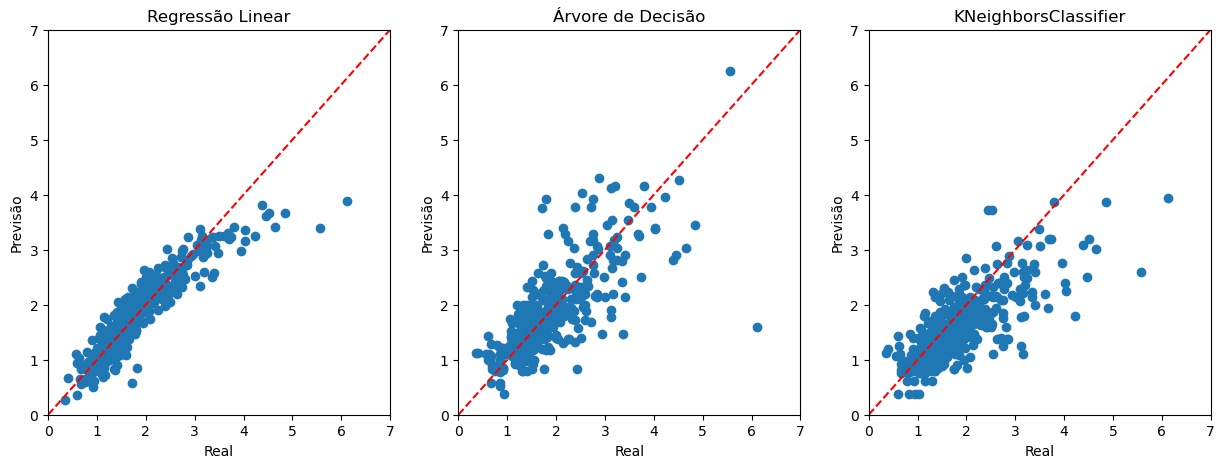

In [27]:
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))

#Regressão Linear
ax[0].scatter(y_test/100000, ln_pred/100000)
ax[0].plot([0,700000],[0,700000],'--r') 

#Árvore de Decisão
ax[1].scatter(y_test/100000, tree_pred/100000)
ax[1].plot([0,700000],[0,700000],'--r') 

#KNN
ax[2].scatter(y_test/100000, knn_pred/100000)
ax[2].plot([0,700000],[0,700000],'--r') 


ax[0].set(xlim = (0, 7),ylim = (0, 7))
ax[0].set_title('Regressão Linear')
ax[0].set_xlabel('Real')
ax[0].set_ylabel('Previsão')

ax[1].set(xlim = (0, 7),ylim = (0, 7))
ax[1].set_title('Árvore de Decisão')
ax[1].set_xlabel('Real')
ax[1].set_ylabel('Previsão')

ax[2].set(xlim = (0, 7),ylim = (0, 7))
ax[2].set_title('KNeighborsClassifier')
ax[2].set_xlabel('Real')
ax[2].set_ylabel('Previsão')

plt.show()

##

É perceptível que o gráfico da Regressão Linear teve uma menor dispersão nas suas previsões, mostrando que as previsões estão mais próximas dos valores reais quanto aos outros modelos, tendo um melhor resultado.

Dado o melhor resultado do primeiro modelo, ele será utilizado para a previsão dos dados de teste.

## Importando e compreendendo dados para serem previstos

In [28]:
testData = pd.read_csv('test.csv')

In [29]:
testData.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [30]:
testData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [31]:
# Analisando possível duplicidade nos dados.
testData.duplicated().sum()

np.int64(0)

In [32]:
testData.shape

(1459, 80)

In [33]:
(testData.isnull().sum()/testData.shape[0]).sort_values(ascending = False).head(35)

PoolQC          0.997944
MiscFeature     0.965045
Alley           0.926662
Fence           0.801234
MasVnrType      0.612748
FireplaceQu     0.500343
LotFrontage     0.155586
GarageYrBlt     0.053461
GarageCond      0.053461
GarageFinish    0.053461
GarageQual      0.053461
GarageType      0.052090
BsmtCond        0.030843
BsmtQual        0.030158
BsmtExposure    0.030158
BsmtFinType1    0.028787
BsmtFinType2    0.028787
MasVnrArea      0.010281
MSZoning        0.002742
BsmtHalfBath    0.001371
Utilities       0.001371
Functional      0.001371
BsmtFullBath    0.001371
BsmtFinSF1      0.000685
Exterior1st     0.000685
TotalBsmtSF     0.000685
BsmtUnfSF       0.000685
BsmtFinSF2      0.000685
SaleType        0.000685
KitchenQual     0.000685
GarageCars      0.000685
GarageArea      0.000685
Exterior2nd     0.000685
Condition2      0.000000
Condition1      0.000000
dtype: float64

##
Limpeza de dados nulos

In [34]:
# Eliminando colunas com mais de 10% de dados nulos.
eliminateTest = testData.columns[(testData.isnull().sum()/testData.shape[0]) > 0.1]

In [35]:
testData = testData.drop(eliminateTest, axis = 1)

In [36]:
# Removendo colunas com dados categóricos.
testobjElm = testData.columns[testData.dtypes != 'object']

In [37]:
newtestData = testData.loc[:,testobjElm]

In [38]:
# Visualizando os últimos dados nulos e substituindo-os para -1.
newtestData.isnull().sum().sort_values(ascending = False).head(11)

GarageYrBlt     78
MasVnrArea      15
BsmtHalfBath     2
BsmtFullBath     2
GarageCars       1
GarageArea       1
BsmtFinSF2       1
BsmtUnfSF        1
TotalBsmtSF      1
BsmtFinSF1       1
MSSubClass       0
dtype: int64

In [39]:
newtestData = newtestData.fillna(-1)

## Fazendo previsão com o dataset

In [40]:
# Guardando os dados previstos em uma variável.
test_pred= ln_reg.predict(newtestData)

In [41]:
# Guardando os dados da variável no DataFrame.
newtestData['SalePrice'] = test_pred

In [42]:
# Criando outro DataFrame para enviar na plataforma Kaggle.
resultado = newtestData[['Id','SalePrice']]

In [43]:
# Salvando o resultado em um arquivo CSV.
resultado.to_csv('resultado.csv', index = False)